🧠 Assessment 1 — Deep Learning Project (Track 1: Kaggle)
WiDS Worldwide Global Datathon 2026

1️⃣ Written Description of the Competition Task

The WiDS Worldwide Global Datathon 2026 is a machine learning competition focused on solving a real-world predictive problem using structured/tabular data. The objective of the competition is to develop a model that can accurately predict a target variable based on a set of input features provided in the dataset.

Participants are required to:

Understand the problem context and dataset structure
Perform data preprocessing and exploratory data analysis (EDA)
Develop a predictive model using machine learning or deep learning techniques
Evaluate model performance using a predefined evaluation metric

This competition emphasizes both data understanding and model development, making it suitable for applying deep learning techniques on tabular data.

2️⃣ Dataset Overview and Evaluation Metric Explanation
📊 Dataset Overview

The dataset consists of four main files:

• Training Dataset (train.csv)
Contains input features and the corresponding target variable
Used to train the predictive model
Represents a supervised learning setup

• Test Dataset (test.csv)
Contains input features only (no target variable)
Used to generate predictions for submission

• Metadata (metaData.csv)
Provides descriptions of each feature
Helps in understanding variable types and meanings
Useful during EDA and preprocessing

• Sample Submission (sample_submission.csv)
Shows the required submission format
Ensures predictions follow Kaggle requirements

📌 Dataset Characteristics
Structured/tabular dataset
Includes numerical and categorical features
May contain missing values
Requires preprocessing before modeling

📐 Evaluation Metric

The performance of the model is evaluated using AUC-ROC (Area Under the Receiver Operating Characteristic Curve).

AUC measures the model’s ability to distinguish between classes
A score close to 1.0 indicates excellent performance
A score of 0.5 indicates random guessing

This metric is particularly suitable for classification problems, especially when dealing with imbalanced datasets.

3️⃣ Exploratory Data Analysis (EDA) / Baseline Notebook
📌 Objective of EDA

The purpose of EDA is to:

Understand the dataset structure
Identify missing values
Analyze feature distributions
Detect patterns and relationships

📊 Basic Data Inspection

In [2]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
meta = pd.read_csv("metaData.csv")

train.head()
train.shape

(221, 37)

📊 Dataset Information

In [3]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   event_id                      221 non-null    int64  
 1   num_perimeters_0_5h           221 non-null    int64  
 2   dt_first_last_0_5h            221 non-null    float64
 3   low_temporal_resolution_0_5h  221 non-null    int64  
 4   area_first_ha                 221 non-null    float64
 5   area_growth_abs_0_5h          221 non-null    float64
 6   area_growth_rel_0_5h          221 non-null    float64
 7   area_growth_rate_ha_per_h     221 non-null    float64
 8   log1p_area_first              221 non-null    float64
 9   log1p_growth                  221 non-null    float64
 10  log_area_ratio_0_5h           221 non-null    float64
 11  relative_growth_0_5h          221 non-null    float64
 12  radial_growth_m               221 non-null    float64
 13  radia

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
count,2.210000e+02,221.000000,221.000000,221.000000,221.000000,221.000000,2.210000e+02,221.000000,221.000000,221.000000,...,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000
mean,5.384397e+07,2.063348,0.979869,0.728507,619.131641,26.332398,1.789087e-01,6.167128,4.683276,0.389346,...,0.046000,-0.004971,0.172704,1.617188,0.551690,15.429864,2.841629,6.782805,37.567626,0.312217
std,2.507456e+07,2.578859,1.738052,0.445739,1447.723668,187.437018,1.302001e+00,40.467370,2.083529,1.340348,...,0.171690,0.371909,0.329210,37.789199,46.760648,7.921250,1.974217,1.571876,25.902361,0.464450
min,1.089246e+07,1.000000,0.000000,0.000000,0.037525,-0.000022,-1.437844e-07,-0.000005,0.036838,0.000000,...,0.000000,-0.999995,0.000000,-213.411731,-526.597241,0.000000,0.000000,1.000000,0.001220,0.000000
25%,3.209326e+07,1.000000,0.000000,0.000000,25.219058,0.000000,0.000000e+00,0.000000,3.266487,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,6.000000,12.242322,0.000000
50%,5.244094e+07,1.000000,0.000000,1.000000,110.149250,0.000000,0.000000e+00,0.000000,4.710874,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,3.000000,7.000000,43.109830,0.000000
75%,7.457274e+07,2.000000,1.356107,1.000000,485.092561,0.000000,0.000000e+00,0.000000,6.186399,0.000000,...,0.000000,0.000000,0.071697,0.000000,0.000000,21.000000,5.000000,8.000000,63.938706,1.000000
max,9.933973e+07,17.000000,4.994457,1.000000,11942.392115,2508.041442,1.788970e+01,520.443033,9.387933,7.827656,...,0.917415,0.994594,0.999995,277.110446,383.099186,23.000000,6.000000,9.000000,66.994474,1.000000


📊 Missing Values Analysis

In [4]:
train.isnull().sum().sort_values(ascending=False)

,0
event_id,0
num_perimeters_0_5h,0
dt_first_last_0_5h,0
low_temporal_resolution_0_5h,0
area_first_ha,0
area_growth_abs_0_5h,0
area_growth_rel_0_5h,0
area_growth_rate_ha_per_h,0
log1p_area_first,0
log1p_growth,0


👉 Interpretation (write in report):

Identify features with high missing values
Decide whether to fill or drop

📊 Target Distribution (IMPORTANT)

In [6]:
train.columns

Index(['event_id', 'num_perimeters_0_5h', 'dt_first_last_0_5h',
       'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h',
       'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first',
       'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h',
       'radial_growth_m', 'radial_growth_rate_m_per_h',
       'centroid_displacement_m', 'centroid_speed_m_per_h',
       'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos',
       'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h',
       'dist_slope_ci_0_5h', 'closing_speed_m_per_h',
       'closing_speed_abs_m_per_h', 'projected_advance_m',
       'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_cos',
       'alignment_abs', 'cross_track_component', 'along_track_speed',
       'event_start_hour', 'event_start_dayofweek', 'event_start_month',
       'time_to_hit_hours', 'event'],
      dtype='object')

In [7]:
train['event'].value_counts(normalize=True)

,proportion
event,
0,0.687783
1,0.312217


👉 Interpretation:

Check if dataset is balanced or imbalanced
Justify use of AUC metric

📊 Correlation Analysis

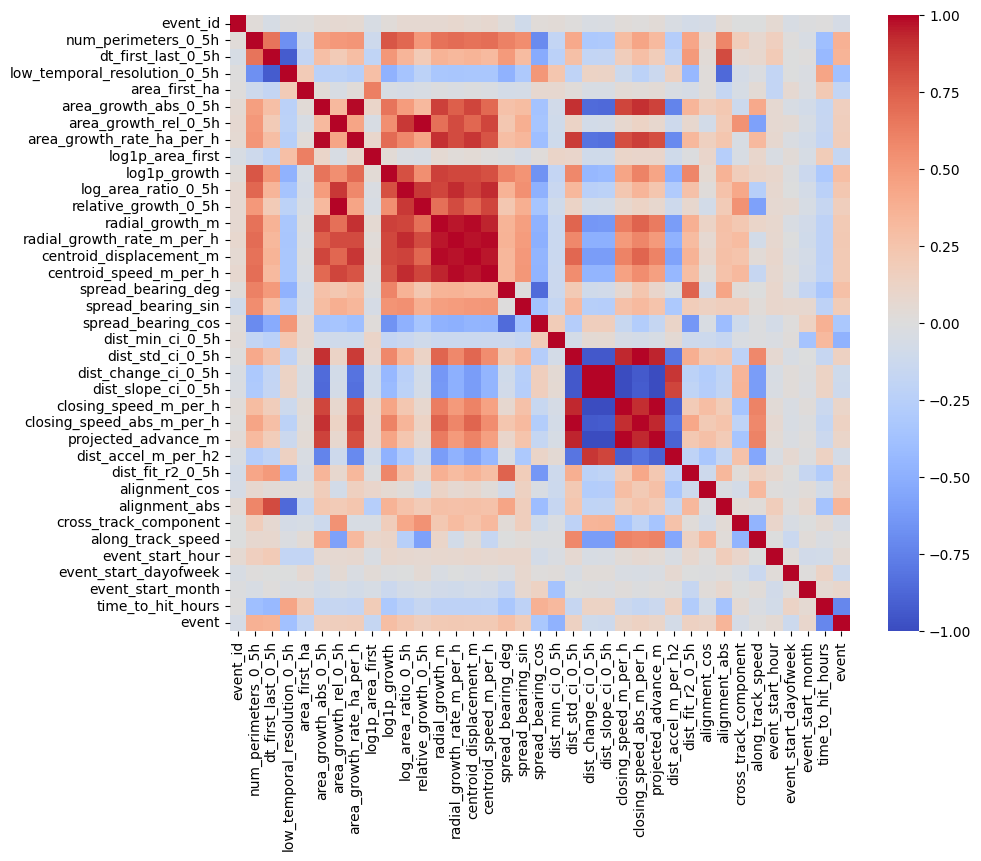

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(train.corr(), cmap="coolwarm")
plt.show()

4️⃣ A Working Baseline Deep Learning Model
📌 Model Description

A baseline model is implemented using a feedforward neural network (Multilayer Perceptron) suitable for tabular data.

🧠 Model Architecture

In [9]:
import torch
import torch.nn as nn

class BaselineModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

Split the Dataset

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split

train = pd.read_csv("train.csv")

X = train.drop(columns=["event_id","event"])
y = train["event"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train a Simple Baseline Model

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=5000))])

In [15]:
from sklearn.metrics import roc_auc_score

y_pred_prob = model.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val, y_pred_prob)

print("Baseline AUC:", auc)

Baseline AUC: 0.9012345679012346
